In [50]:
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm.auto import tqdm
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../../")

import pyanalib.pandas_helpers as ph
import warnings
from pyanalib.split_df_helpers import *
from makedf.util import *
from analysis_village.gump.gump_cuts import *

# Colors for plots
HAWKS_COLORS = ["#315031", "#d54c28", "#1e3f54", "#c89648", "#43140b", "#95af8b"]
FONTSIZE = 14
plt.style.use('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/dune.mplstyle')
output_prefix="/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/flux_checks"

In [45]:
dfs = []
prefix = "/exp/sbnd/data/users/nrowe/GUMP/sbn-rewgted-6/ICARUS_flux_checks/"
files = os.listdir(prefix)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for f in tqdm(files, desc="Loading flux files"):
        # Process the file
        tempdf = all_cuts(load_dfs(f"{prefix}{f}", ['evt'])['evt'], "ICARUS", 4)
        dfs.append(tempdf)

Igumpdf = pd.concat(dfs)

Loading flux files:   0%|          | 0/261 [00:00<?, ?it/s]

In [29]:
dfs = []
prefix = "/exp/sbnd/data/users/nrowe/GUMP/sbn-rewgted-6/flux_checks/"
files = os.listdir(prefix)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for f in tqdm(files, desc="Loading flux files"):
        # Process the file
        tempdf = all_cuts(load_dfs(f"{prefix}{f}", ['evt'])['evt'], "SBND", 1)
        dfs.append(tempdf)

gumpdf = pd.concat(dfs)

Loading flux files:   0%|          | 0/2000 [00:00<?, ?it/s]

In [30]:
cathdf = cathode_cut(gumpdf)

/home/nrowe/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/matplotlib/axes/_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/home/nrowe/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/matplotlib/axes/_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


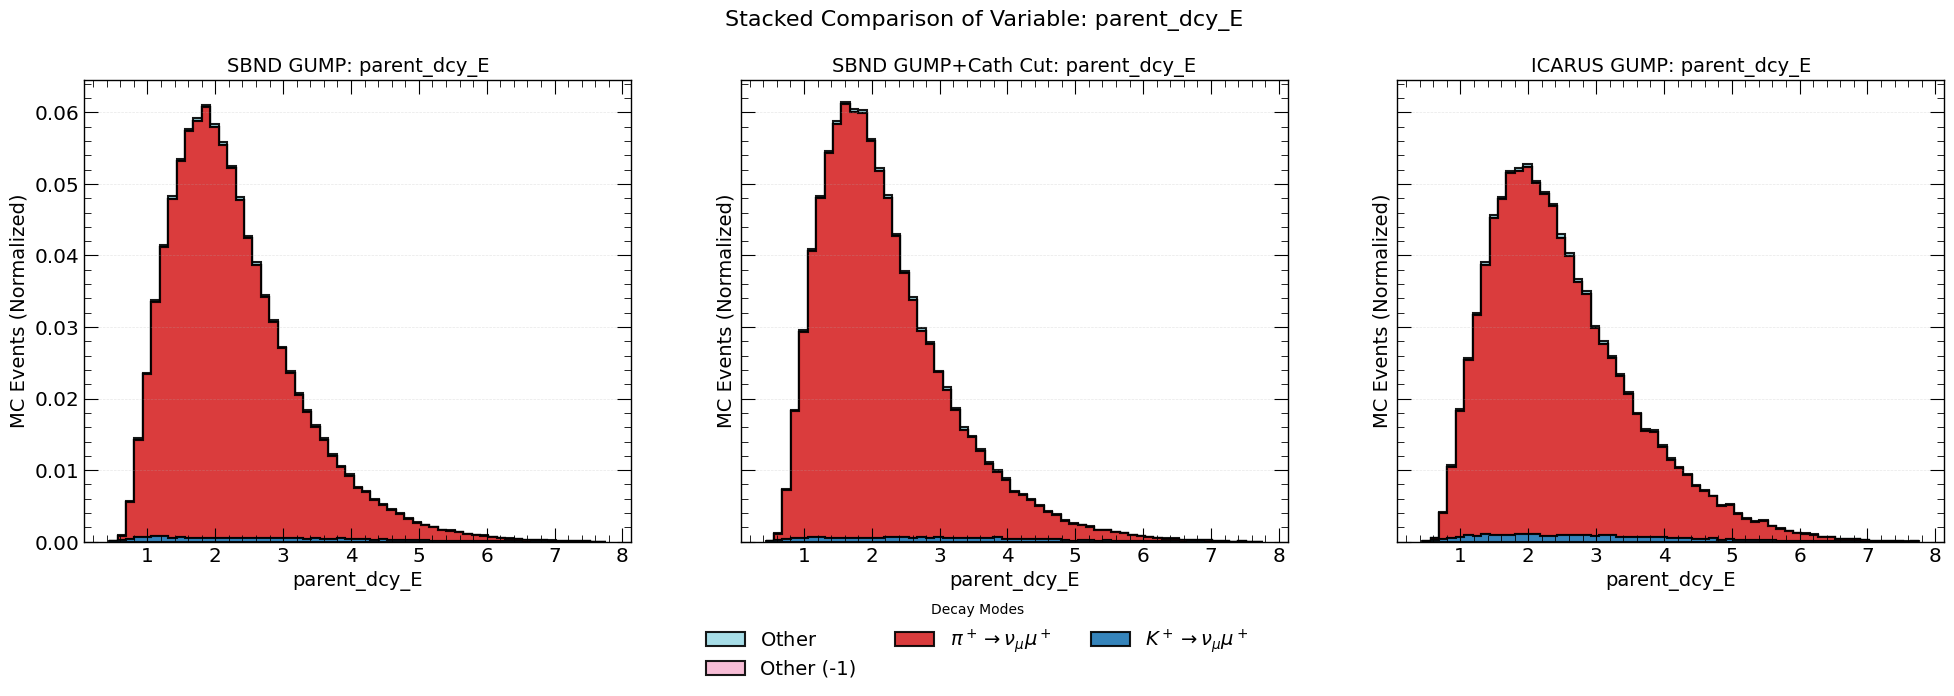

<Figure size 640x480 with 0 Axes>

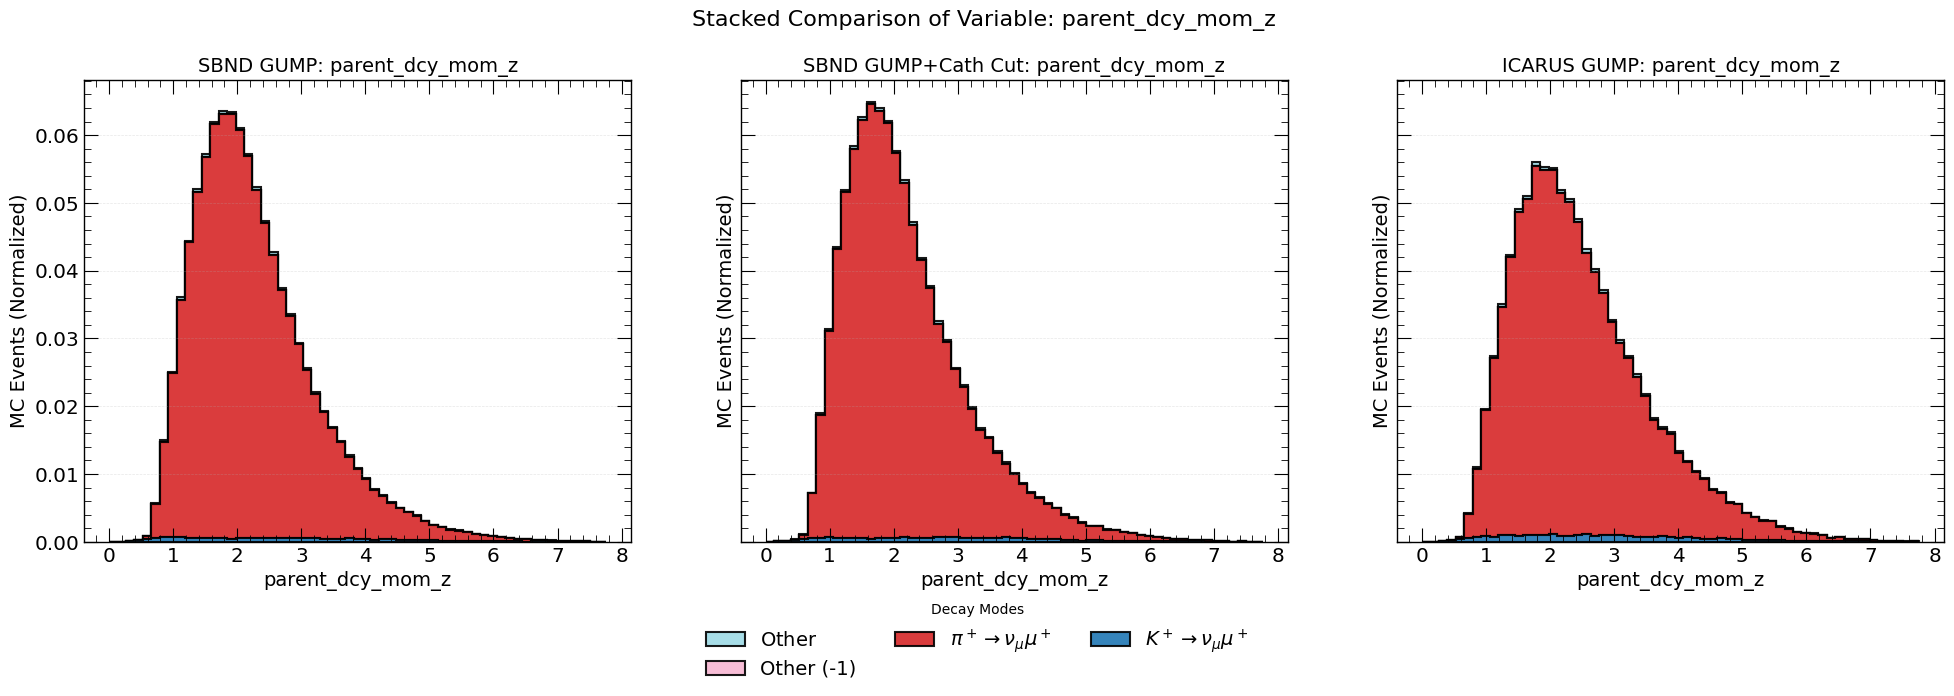

<Figure size 640x480 with 0 Axes>

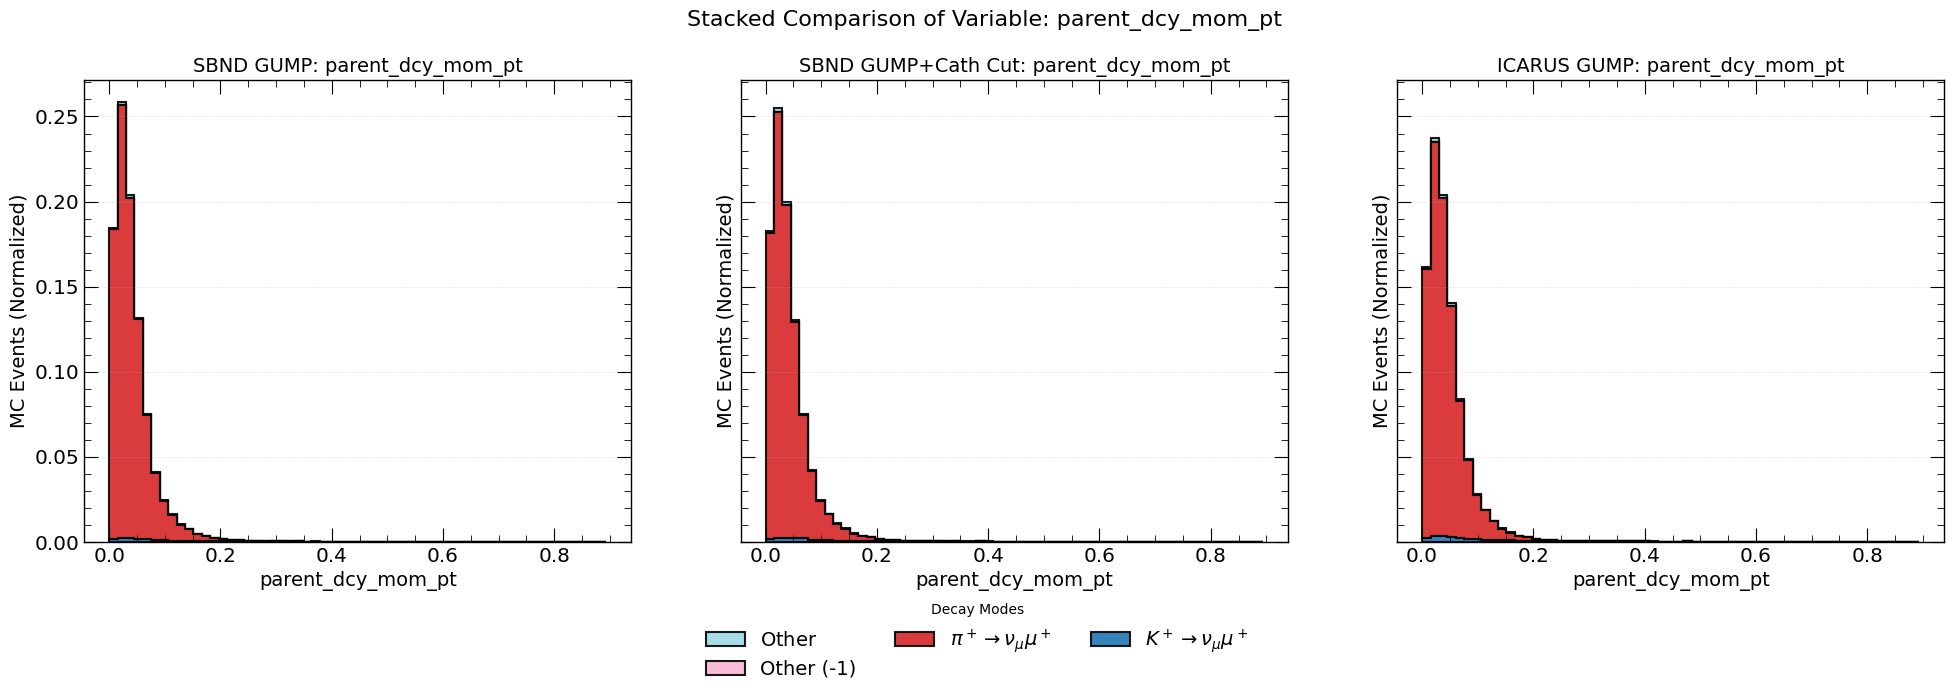

<Figure size 640x480 with 0 Axes>

In [64]:
# 1. Define the mappings
dcy_mode_map = {
    1: r"$K^0_L \to \nu_e \pi^- e^+$", 2: r"$K^0_L \to \bar{\nu}_e \pi^+ e^-$",
    3: r"$K^0_L \to \nu_\mu \pi^- \mu^+$", 4: r"$K^0_L \to \bar{\nu}_\mu \pi^+ \mu^-$",
    5: r"$K^+ \to \nu_\mu \mu^+$", 6: r"$K^+ \to \nu_e \pi^0 e^+$",
    7: r"$K^+ \to \nu_\mu \pi^0 \mu^+$", 8: r"$K^- \to \bar{\nu}_\mu \mu^-$",
    9: r"$K^- \to \bar{\nu}_e \pi^0 e^-$", 10: r"$K^- \to \bar{\nu}_\mu \pi^0 \mu^-$",
    11: r"$\mu^+ \to \bar{\nu}_\mu \nu_e e^+$", 12: r"$\mu^- \to \nu_\mu \bar{\nu}_e e^-$",
    13: r"$\pi^+ \to \nu_\mu \mu^+$", 14: r"$\pi^- \to \bar{\nu}_\mu \mu^-$"
}

# 2. Pre-processing Functions
def add_decay_labels(df, mapping):
    df['decay_label'] = df['parent_dcy_mode'].map(lambda x: mapping.get(x, f'Other ({x})'))
    return df

def group_small_categories(df, threshold=0.01):
    """Groups categories that appear less than 'threshold' percent of the time."""
    # Calculate proportions
    counts = df['decay_label'].value_counts(normalize=True)
    # Find labels that are below threshold
    small_labels = counts[counts < threshold].index
    # Group them into 'Other'
    df.loc[df['decay_label'].isin(small_labels), 'decay_label'] = r"$\text{Other}$"
    return df

# Apply labels and grouping
for df in [gumpdf, cathdf, Igumpdf]:
    df = add_decay_labels(df, dcy_mode_map)
    df = group_small_categories(df, threshold=0.01)

# 3. Define variables and prepare dataset
vars_to_plot = ['parent_dcy_E', 'parent_dcy_mom_z', 'parent_dcy_mom_pt']

for df in [gumpdf, cathdf, Igumpdf]:
    df['parent_dcy_mom_pt'] = np.sqrt(df['parent_dcy_mom_x']**2 + df['parent_dcy_mom_y']**2)
    
# Determine consistent order: sort labels, but force 'Other' to be the last one
all_labels = sorted(list(set(gumpdf['decay_label'].unique()) | set(cathdf['decay_label'].unique())))
if r"$\text{Other}$" in all_labels:
    all_labels.remove(r"$\text{Other}$")
    all_labels.append(r"$\text{Other}$")

# --- MAIN PLOTTING LOOP ---
for var in vars_to_plot:
    combined_data = np.concatenate([gumpdf[var].dropna(), cathdf[var].dropna()])
    b = np.linspace(np.min(combined_data), np.max(combined_data), 60)

    fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)
    colors = plt.cm.tab20(np.linspace(0, 1, len(all_labels)))

    for ax, df, label_prefix in zip(axes, [gumpdf, cathdf, Igumpdf], ["SBND GUMP", "SBND GUMP+Cath Cut", "ICARUS GUMP"]):
        stacked_data = []
        labels_present = []
        color_stack = []

        for i, dcy_label in enumerate(all_labels):
            subset = df[df['decay_label'] == dcy_label][var]
            if not subset.empty:
                stacked_data.append(subset)
                labels_present.append(dcy_label)
                color_stack.append(colors[i])

        # Plot with normalization weights
        ax.hist(stacked_data, bins=b, stacked=True, 
                label=labels_present, color=color_stack,
                edgecolor='black', 
                weights=[np.ones_like(s)/len(df) for s in stacked_data], 
                alpha=0.9, histtype='stepfilled')

        ax.set_title(f'{label_prefix}: {var}', fontsize=FONTSIZE)
        ax.set_xlabel(var, fontsize=FONTSIZE)
        ax.set_ylabel('MC Events (Normalized)', fontsize=FONTSIZE)
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle(f'Stacked Comparison of Variable: {var}', fontsize=16)
    
    handles, labels = axes[1].get_legend_handles_labels()
    # fig.legend(handles, labels, title='Decay Modes', loc='lower center', 
    #            ncol=3, fontsize=FONTSIZE, bbox_to_anchor=(0.5, -0.15))
    fig.legend(handles, labels, title='Decay Modes', loc='lower center', 
               ncol=3, fontsize=FONTSIZE)
    #plt.tight_layout(rect=[0, 0, 1, 0.96]) 
    plt.subplots_adjust(bottom=0.22) 
    plt.savefig(f"{output_prefix}/{var}.png")
    plt.show()
    plt.clf()

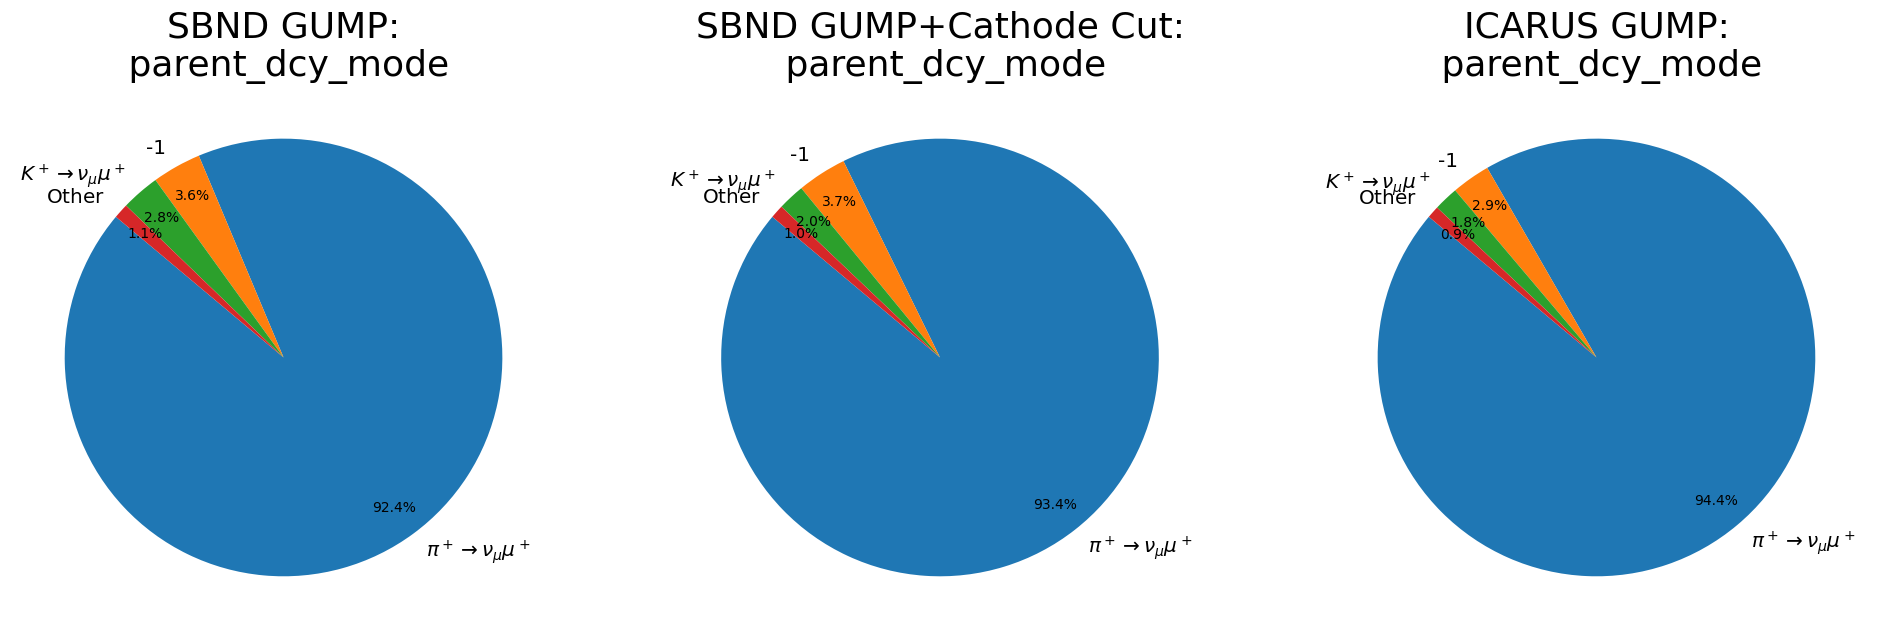

<Figure size 640x480 with 0 Axes>

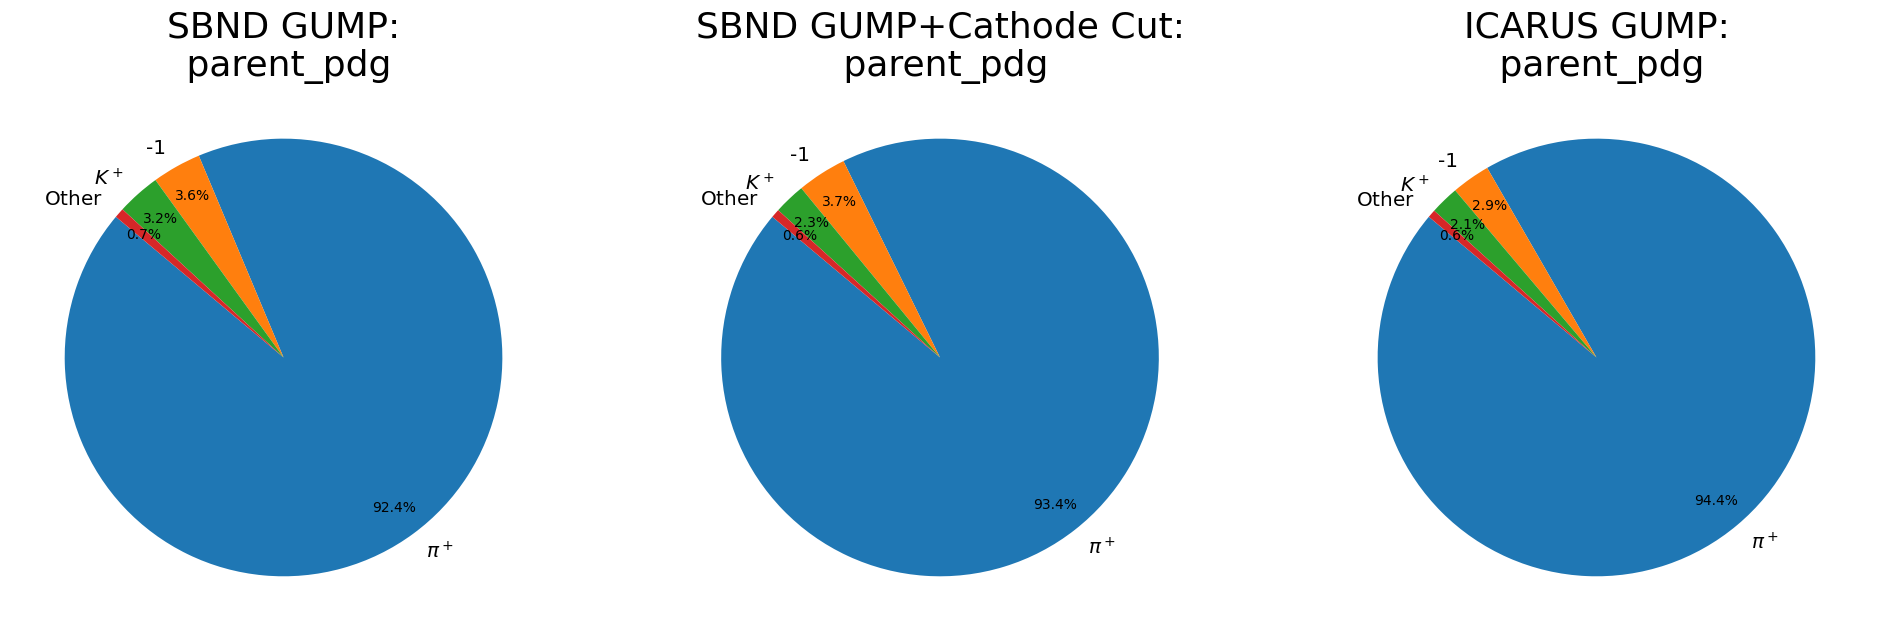

<Figure size 640x480 with 0 Axes>

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# Define your mappings for LaTeX labels
dcy_mode_map = {
    1: r"$K^0_L \to \nu_e \pi^- e^+$", 2: r"$K^0_L \to \bar{\nu}_e \pi^+ e^-$",
    3: r"$K^0_L \to \nu_\mu \pi^- \mu^+$", 4: r"$K^0_L \to \bar{\nu}_\mu \pi^+ \mu^-$",
    5: r"$K^+ \to \nu_\mu \mu^+$", 6: r"$K^+ \to \nu_e \pi^0 e^+$",
    7: r"$K^+ \to \nu_\mu \pi^0 \mu^+$", 8: r"$K^- \to \bar{\nu}_\mu \mu^-$",
    9: r"$K^- \to \bar{\nu}_e \pi^0 e^-$", 10: r"$K^- \to \bar{\nu}_\mu \pi^0 \mu^-$",
    11: r"$\mu^+ \to \bar{\nu}_\mu \nu_e e^+$", 12: r"$\mu^- \to \nu_\mu \bar{\nu}_e e^-$",
    13: r"$\pi^+ \to \nu_\mu \mu^+$", 14: r"$\pi^- \to \bar{\nu}_\mu \mu^-$"
}

pdg_map = {
    130: r"$K^0_L$", 321: r"$K^+$", -321: r"$K^-$", 
    -13: r"$\mu^+$", 13: r"$\mu^-$", 211: r"$\pi^+$", -211: r"$\pi^-$"
}

# Helper function to group small categories
def group_small_categories(counts, threshold=0.01):
    total = counts.sum()
    limit = total * threshold
    
    large = counts[counts >= limit]
    small = counts[counts < limit]
    
    if not small.empty:
        # Create a new series entry for 'Other'
        other_series = pd.Series({'Other': small.sum()})
        return pd.concat([large, other_series])
    return large

columns_to_plot = {'parent_dcy_mode': dcy_mode_map, 'parent_pdg': pdg_map}

for col, mapping in columns_to_plot.items():
    # 1. Get counts and group small categories
    counts_Igum = group_small_categories(gumpdf[col].value_counts())
    counts_gum = group_small_categories(Igumpdf[col].value_counts())
    counts_cat = group_small_categories(cathdf[col].value_counts())
    
    # 2. Create the figure
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    # Helper to plot pie
    def plot_pie(ax, counts, title):
        # Map IDs to labels, adding 'Other' specifically
        labels = [mapping.get(idx, r"$\text{Other}$" if idx == 'Other' else str(idx)) for idx in counts.index]
        
        ax.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
        ax.set_title(title)

    # 3. Plot both
    plot_pie(axes[0], counts_gum, f"SBND GUMP:\n {col}")
    plot_pie(axes[1], counts_cat, f"SBND GUMP+Cathode Cut:\n {col}")
    plot_pie(axes[2], counts_Igum, f"ICARUS GUMP:\n {col}")
    
    #plt.tight_layout()
    plt.savefig(f"{output_prefix}/{col}.png")
    plt.show()
    plt.clf()

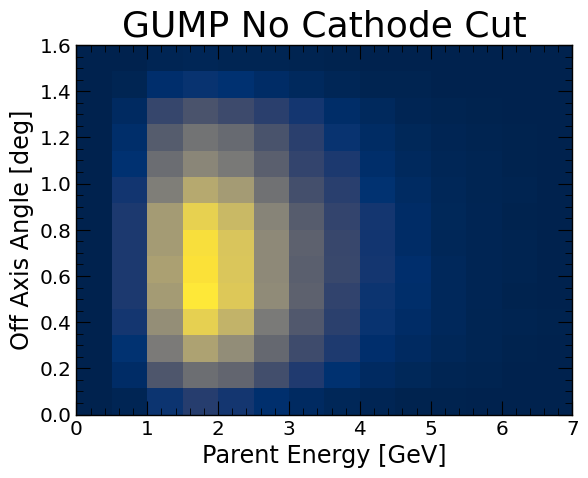

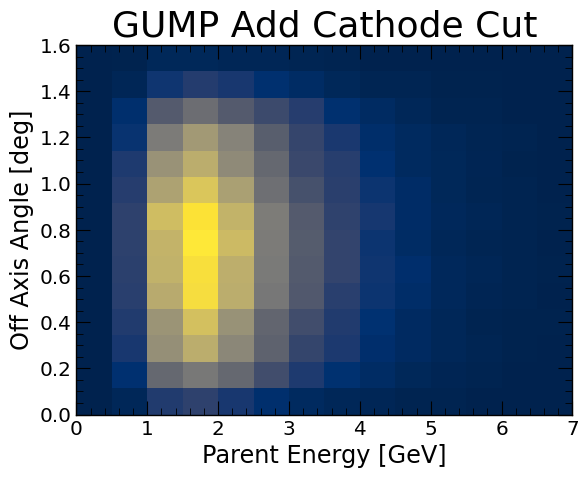

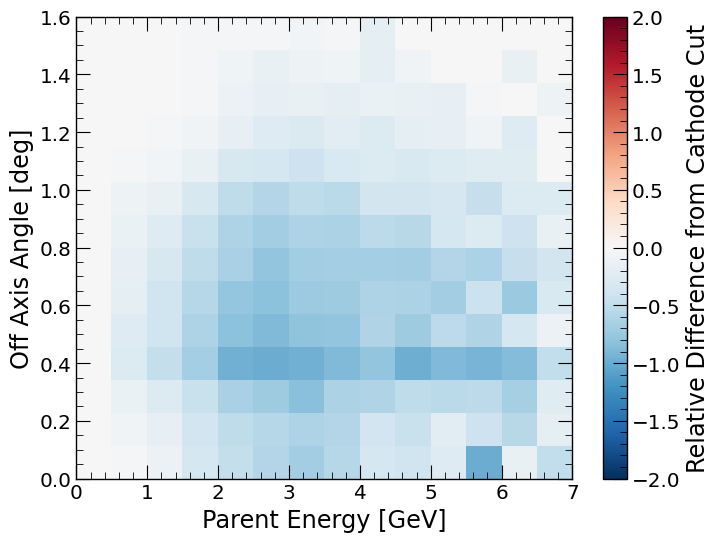

In [84]:
def add_angle(df):
    beam_origin = np.array([74, 0.0, -11250.0])# x, y, z
    vtx = np.array([df['slc_vtx_x'].to_numpy(), df['slc_vtx_y'].to_numpy(), df['slc_vtx_z'].to_numpy()])

    adj = vtx[2] - beam_origin[2]
    opp = np.sqrt((vtx[0] - beam_origin[0])**2 +(vtx[1] - beam_origin[1])**2 )

    OAA = np.rad2deg(np.arctan(opp/adj))
    df['OAA'] = OAA
    return df
    
gumpdf = add_angle(gumpdf)
cathdf = add_angle(cathdf)
xedges = np.linspace(0., 7., 15)
yedges = np.linspace(0., 1.6, 15)
b = [xedges, yedges]

plt.title('GUMP No Cathode Cut')
plt.xlabel('Parent Energy [GeV]')
plt.ylabel('Off Axis Angle [deg]')
n1, _, _, _ = plt.hist2d(gumpdf.parent_dcy_E[~gumpdf.parent_dcy_E.isna()], gumpdf.OAA[~gumpdf.parent_dcy_E.isna()], bins=b)
plt.show()

plt.title('GUMP Add Cathode Cut')
plt.xlabel('Parent Energy [GeV]')
plt.ylabel('Off Axis Angle [deg]')
n2, _, _, _ = plt.hist2d(cathdf.parent_dcy_E[~cathdf.parent_dcy_E.isna()], cathdf.OAA[~cathdf.parent_dcy_E.isna()], bins=b)
plt.show()

ratio = np.divide(n2-n1, n2, out=np.zeros_like(n1), where=n2 != 0)

# 3. Plot the result
plt.figure(figsize=(8, 6))
# origin='lower' aligns the (0,0) index with the bottom-left of the plot
# extent sets the axis coordinates based on your bin edges
plt.imshow(ratio.T, origin='lower', 
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
           aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)

plt.colorbar(label='Relative Difference from Cathode Cut')
plt.xlabel('Parent Energy [GeV]')
plt.ylabel('Off Axis Angle [deg]')
plt.show()